## MMTHE01 - Masters Thesis

### E1. Thesis - Apply and Evaluate different XAI methods - Case Study with SVM Model
* Applying XAI on a Supervised Learning AI model (SVM with SMOTE)
* Applying Model Agnostic Perturbation-based local XAI methods: SHAP, LIME Anchors, Counterfactual

#### Importing the libraries

In [1]:
### import general libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import re

from sklearn.preprocessing import LabelEncoder

In [2]:
### Import libraries to save models
import pickle
from tensorflow.keras.models import Model, load_model

In [3]:
# Fix the random seed so that the same sample is always chosen
np.random.seed(1)

In [4]:
# Check your current working directory
cwd = os.getcwd()

# Build the full path
full_path = r"C:\Users\eaber\Documents\Master Thesis Final\Analysis"

# Check if it exists before changing
if os.path.exists(full_path):
    os.chdir(full_path)
    print("Changed directory to:", full_path)
else:
    print("Folder does not exist:", full_path)

Folder does not exist: C:\Users\eaber\Documents\Master Thesis Final\Analysis


#### Loading the test and train datasets

In [5]:
with open("saved_data/Oversampled_datasets_folder.pkl","rb") as f:
    X_train_np, y_train_np, X_test_np, y_test_np, X_train_scaled_np, X_test_scaled_np = pickle.load(f)

In [6]:
### Import the pickle saved dataset
with open("saved_data/selected_features_final.pkl","rb") as f:
    selected_features_final = pickle.load(f)

In [7]:
if 'default_status' in selected_features_final:
    selected_features_final.remove('default_status')
    
feature_names = [re.sub(r"[ <>+]", "_", c).replace(" ", "_") for c in selected_features_final]

In [8]:
# Convert to dataframe
#X_train = pd.DataFrame(X_train_np, columns=feature_names).apply(pd.to_numeric)
#X_test = pd.DataFrame(X_test_np, columns=feature_names).apply(pd.to_numeric)
X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=feature_names).apply(pd.to_numeric)
X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=feature_names).apply(pd.to_numeric)

y_train = pd.DataFrame(y_train_np, columns=['default_status'])
y_test = pd.DataFrame(y_test_np, columns=['default_status'])

#### Loading the models

In [9]:
# Define pipeline with scaling + LinearSVC
pipeline = Pipeline([
    ('svc', LinearSVC(C=1.0, loss="squared_hinge", class_weight='balanced', max_iter=10000, random_state=1))
])

In [10]:
# load SVM model
with open("saved_models/svm_pipeline_Oversampled.pkl", "rb") as f:
    pipeline = pickle.load(f)

In [11]:
model = pipeline.named_steps["svc"]

#### Function to combine scores of One Hot Encoded (OHE) features and show original feature names

In [12]:
original_features = ['title', 'sub_grade', 'issue_year', 'verification_status', 'loan_amnt', 'home_ownership', 'mo_sin_old_il_acct', 'dti', 
                     'acc_open_past_24mths', 'total_il_high_credit_limit', 'issue_month', 'mths_since_recent_inq', 'total_bc_limit', 'purpose',
                     'tot_hi_cred_lim', 'emp_title', 'num_tl_op_past_12m', 'num_bc_tl', 'avg_cur_bal', 'annual_inc', 'num_actv_bc_tl',
                     'percent_bc_gt_75', 'pub_rec_bankruptcies', 'term_in_months', 'mo_sin_rcnt_tl', 'pct_tl_nvr_dlq', 'mo_sin_old_rev_tl_op', 
                     'num_actv_rev_tl', 'num_tl_30dpd', 'earliest_cr_line_year', 'mths_since_recent_bc', 'revol_bal', 'revol_util', 'total_rev_hi_lim', 
                     'inq_last_6mths', 'bc_util', 'num_accts_ever_120_pd', 'earliest_cr_line_month', 'mort_acc', 'bc_open_to_buy', 'num_tl_90g_dpd_24m', 
                     'total_bal_ex_mort', 'num_bc_sats', 'num_il_tl', 'delinq_2yrs', 'num_rev_accts', 'num_op_rev_tl', 'pub_rec', 'initial_list_status',
                     'tax_liens', 'open_acc', 'delinq_amnt', 'total_acc', 'emp_length', 'collections_12_mths_ex_med', 'mo_sin_rcnt_rev_tl_op']

In [13]:
# Initialize a list to hold aggregated rows
agg_rows = []

In [14]:
def aggregate_ohe_importances_vectorized(df, feature_col='feature', importance_col='importance'):
    """
    Aggregate one-hot encoded features into their original categorical variable in a vectorized way.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing feature importances.
    ohe_features : list of str
        List of base feature names that were one-hot encoded.
    feature_col : str
        Column name for feature names.
    importance_col : str
        Column name for signed feature importance values.

    Returns:
    --------
    agg_df : pd.DataFrame
        Aggregated DataFrame with 'feature', 'importance', 'abs_importance', sorted by abs_importance descending.
    """
    
    df = df.copy()
    
    # 1. Replace original columns with base feature name
    for base_col in original_features:
        if base_col == 'title':
            df.loc[df[feature_col].str.startswith(base_col), feature_col] = base_col
        elif base_col == 'pub_rec':
            pattern = r'\b' + re.escape(base_col) + r'\b'
            df[feature_col] = df[feature_col].str.replace(pattern, base_col, regex=True)
        else:
            df[feature_col] = df[feature_col].apply(lambda x: base_col if base_col in x else x)
    
    # 2. Group by feature and sum importance values
    agg_df = df.groupby(feature_col, as_index=False)[importance_col].sum()
    
    # 3. Create absolute importance column
    agg_df['abs_'+importance_col] = agg_df[importance_col].abs()
    
    # 4. Sort by absolute importance descending
    agg_df = agg_df.sort_values(by='abs_'+importance_col, ascending=False).reset_index(drop=True)
    
    return agg_df

In [15]:
# Increase global font sizes
plt.rcParams.update({
    "font.size": 14,           # base font size
    "axes.titlesize": 16,      # title
    "axes.labelsize": 14,      # x/y labels
    "xtick.labelsize": 14,     # x tick labels
    "ytick.labelsize": 14      # y tick labels
})

### 5 Applying XAI methods to the SVM Model

#### 5.1 Applying SHAP (Local Implementation) to the SVM Model
* E1A. Thesis - Test different XAI methods with the SVM Model (SHAP-Local)

In [16]:
idx = 1

In [17]:
### import
import shap
shap.initjs()

In [18]:
start_time = time.time()

In [19]:
shap_explainer = shap.LinearExplainer(model, X_train_scaled)

In [20]:
shap_values = shap_explainer.shap_values(X_test_scaled.iloc[idx])

In [21]:
end_time = time.time()
training_time = end_time - start_time
print(f"SHAP on SVM (Explanation Time): {training_time:.2f} seconds")

SHAP on SVM (Explanation Time): 0.03 seconds


##### Adding SHAP values to an arbitrary bar chart

In [22]:
# Convert SHAP values to DataFrame for easier manipulation
shap_df_ohe = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'shap_value': shap_values,  # numerical SHAP values
})

In [23]:
len(shap_df_ohe)#.head()

109

In [24]:
shap_df = aggregate_ohe_importances_vectorized(shap_df_ohe, feature_col='feature', importance_col='shap_value')
shap_df.to_csv('intermediate_output/XAI all features ranked/SVM_shap_local_allR.csv',index=False)

In [25]:
len(shap_df)#.head()

56

In [26]:
# Sort by absolute SHAP value
shap_top10 = shap_df.sort_values('abs_shap_value', ascending=False).head(10)
shap_top10.to_csv('intermediate_output/XAI top 10 features/SVM_shap_local_top10.csv',index=False)
shap_top10

,feature,shap_value,abs_shap_value
0,sub_grade,-0.249499,0.249499
1,title,-0.156060,0.156060
2,issue_year,-0.123035,0.123035
3,purpose,0.090904,0.090904
4,verification_status,-0.071995,0.071995
5,percent_bc_gt_75,0.065239,0.065239
6,earliest_cr_line_year,-0.056688,0.056688
7,total_bal_ex_mort,-0.054789,0.054789
8,issue_month,0.047502,0.047502
9,home_ownership,-0.046800,0.046800


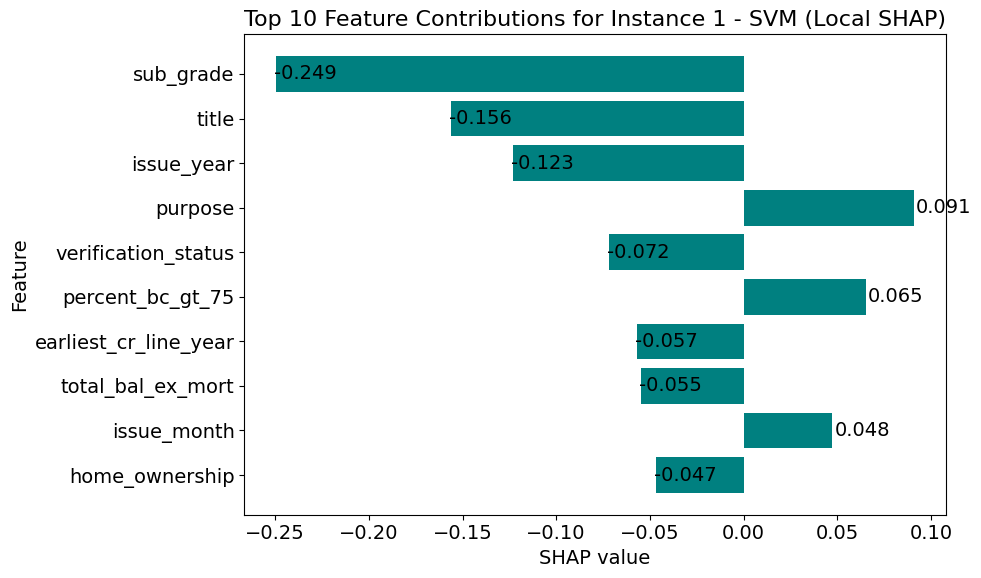

In [27]:
# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(shap_top10['feature'][::-1], shap_top10['shap_value'][::-1], color='teal')
plt.xlabel('SHAP value')
plt.ylabel('Feature')
plt.title(f'Top 10 Feature Contributions for Instance {idx} - SVM (Local SHAP)')

ax = plt.gca()  # get current axes
for i, v in enumerate(shap_top10['shap_value'][::-1]):
    ax.text(v + 0.001 if v > 0 else v - 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/SVM_shap_local_top10',dpi=300)
plt.show()

#### 5.2 Applying LIME to the SVM Model
* E1A. Thesis - Test different XAI methods with the SVM Model (LIME)

In [28]:
import lime
import lime.lime_tabular

In [29]:
feature_names = X_test_scaled.columns.tolist()

In [30]:
X_test_scaled.head()

,acc_open_past_24mths,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earliest_cr_line_month_Apr,...,title,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,verification_status_Not_Verified,verification_status_Source_Verified,verification_status_Verified
0,-1.463339,-0.343983,-0.706375,-0.527756,0.087212,-0.118429,-0.357884,-0.017951,-1.258509,-0.287676,...,1.600503,-0.920415,-1.184783,-0.954903,-0.735588,-0.994118,-0.704208,1.510576,-0.807128,-0.655931
1,0.404425,-0.316488,0.374022,-0.654693,1.203167,-0.118429,-0.357884,-0.017951,-0.324102,-0.287676,...,-0.741852,0.282401,-0.438984,-0.810385,-0.804072,-0.287210,-0.587099,1.510576,-0.807128,-0.655931
2,-0.840751,-0.014043,-0.262383,-0.368140,-0.513686,-0.118429,-0.357884,-0.017951,0.001490,-0.287676,...,-0.330436,-0.503259,-0.853317,0.415858,-0.612315,0.641374,-0.650158,-0.661999,1.238961,-0.655931
3,-0.218163,1.017018,0.705151,2.282226,-0.595952,-0.118429,-0.357884,-0.017951,0.231365,-0.287676,...,2.747480,1.933947,1.218347,0.303058,2.661245,0.547045,1.451799,-0.661999,1.238961,-0.655931
4,-0.057172,-0.572191,0.037484,0.056545,-0.048416,-0.118429,-0.357884,-0.017951,0.105051,-0.287676,...,0.381657,0.041162,-0.273251,0.009249,0.050919,0.010029,0.040671,1.510576,-0.807128,-0.655931


In [31]:
start_time = time.time()

In [32]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test_scaled.values,
    feature_names=feature_names,
    class_names=["non-default", "default"],
    mode='classification',
    verbose=True,
    random_state = 1
)

In [33]:
idx = 1
sample = X_test_scaled.values[idx]

In [34]:
def decision_to_proba(X):
    scores = pipeline.decision_function(X)
    probs = 1 / (1 + np.exp(-scores))  # for binary classification
    return np.vstack([1-probs, probs]).T

In [35]:
lime_exp = lime_explainer.explain_instance(
    data_row=sample,
    predict_fn=decision_to_proba,
    num_features=len(X_test_scaled.columns.tolist())
)

Intercept 0.05077945832059971
Prediction_local [0.35224005]
Right: 0.3544296894998627


In [36]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"LIME on SVM (Explanation Time): {explanation_time:.2f} seconds")

LIME on SVM (Explanation Time): 4.02 seconds


In [37]:
#print(lime_exp.as_list())

In [38]:
from IPython.display import HTML, display
plt.figure(figsize=(12, 8))  # width=12, height=8 inches
plt.tight_layout() 
display(HTML("<style>.container { width:100% !important; }</style>"))
lime_exp.show_in_notebook()

<Figure size 1200x800 with 0 Axes>

In [39]:
# LIME dataframe
# Extract explanation as a list of tuples: [(feature_name, effect), ...]
lime_list = lime_exp.as_list()

# Convert to DataFrame
df_lime_ohe = pd.DataFrame(lime_list, columns=['feature', 'contribution'])

In [40]:
len(df_lime_ohe)

109

In [41]:
df_lime = aggregate_ohe_importances_vectorized(df_lime_ohe, feature_col='feature', importance_col='contribution')
df_lime.to_csv('intermediate_output/XAI all features ranked/SVM_lime_allR.csv',index=False)

In [42]:
len(df_lime)#.head()

56

In [43]:
df_lime10 = df_lime.head(10)

In [44]:
df_lime10.to_csv('intermediate_output/XAI top 10 features/SVM_lime_top10.csv',index=False)

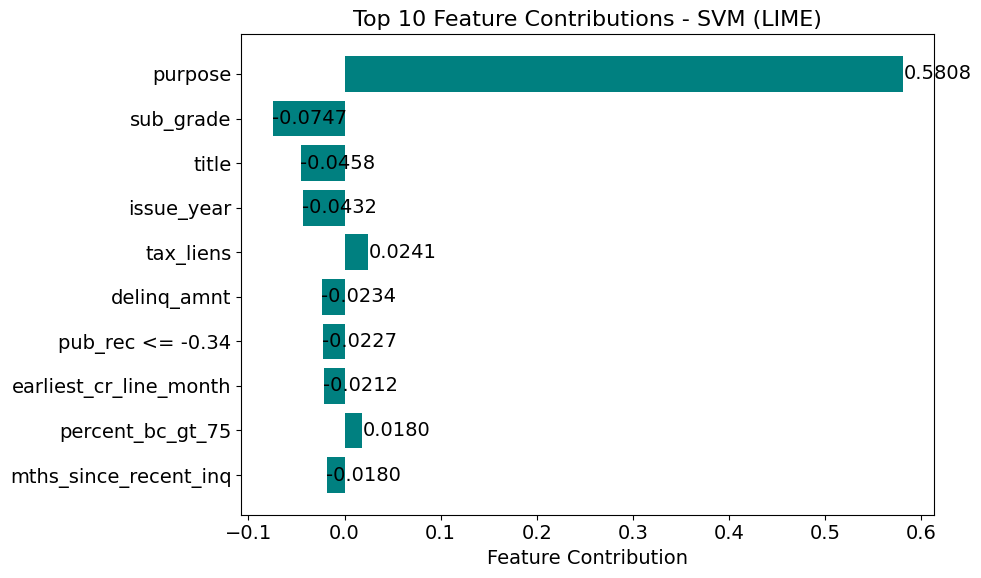

In [45]:
# Plot horizontal bar chart
plt.figure(figsize=(10,6))
bars = plt.barh(df_lime10["feature"], df_lime10["contribution"], color='teal')
plt.xlabel("Feature Contribution")
plt.title("Top 10 Feature Contributions - SVM (LIME)")

# Add labels
for bar, val in zip(bars, df_lime10["contribution"]):
    plt.text(bar.get_width() + 0.001 if val > 0 else bar.get_width() - 0.001, 
             bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center')

plt.gca().invert_yaxis()  # largest on top

plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/SVM_lime_top10',dpi=300)
plt.show()

#### 5.3 Applying Counterfactual to the SVM Model
* E1A. Thesis - Test different XAI methods with the SVM Model (Counterfactual)

In [46]:
from sklearn.metrics import pairwise_distances

In [47]:
# Show floats with 2 decimal places and avoid scientific notation
pd.set_option('display.float_format', '{:.4f}'.format)

In [48]:
# Assume: X_test, model
idx = 1
query_instance = X_test_scaled.iloc[idx].copy()
query_instance_values = query_instance.values

In [49]:
def predict_label(model, x):
    """
    Predict class for a single instance.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x.reshape(1, -1))[0,1]  # probability of class 1
    else:
        return model.predict(x.reshape(1, -1))[0]

In [50]:
def distance(x1, x2):
    """Euclidean distance between two instances"""
    return np.linalg.norm(x1 - x2)

In [51]:
def generate_counterfactual(model, x0, total_cfs=3, max_trials=10000, step_size=0.45):
    """
    Generates counterfactuals using random perturbations.
    """
    cf_list = []
    trials = 0
    
    while len(cf_list) < total_cfs and trials < max_trials:
        # Perturb features randomly
        x_cf = x0 + np.random.normal(0, step_size, size=x0.shape)
        
        # Check if prediction flips
        pred_orig = predict_label(model, x0)
        pred_cf = predict_label(model, x_cf)
        
        # For binary classification, flip the label
        if (pred_orig < 0.5 and pred_cf >= 0.5) or (pred_orig >= 0.5 and pred_cf < 0.5):
            cf_list.append(x_cf)
        
        trials += 1
    
    return np.array(cf_list)

In [52]:
start_time = time.time()

In [53]:
counterfactuals = generate_counterfactual(model=pipeline, x0=query_instance_values, total_cfs=3)

In [54]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"Counterfactual on SVM (Explanation Time): {explanation_time:.2f} seconds")

Counterfactual on SVM (Explanation Time): 0.32 seconds


In [55]:
counterfactuals.shape[0]

3

In [56]:
if counterfactuals.shape[0] == 0:
    print(f"Couldn't find any valid alternative instance for the instance with index {idx}")
else:
    # Create DataFrame for counterfactual(s)
    df_cf = pd.DataFrame(counterfactuals, columns=X_test_scaled.columns)
    
    # Combine original and counterfactual without hierarchical index
    df_compare = pd.concat([query_instance.to_frame().T, df_cf], axis=0)
    df_compare.index = ['Original'] + [f'Counterfactual_{i+1}' for i in range(len(df_cf))]
    
    # Transpose so features are rows (no hierarchical index)
    df_transposed = df_compare.T
    
    # Compute delta with first counterfactual (or modify for multiple)
    #df_transposed['delta'] = df_transposed['Counterfactual_1'] - df_transposed['Original']
    df_transposed.reset_index(inplace=True)
    df_transposed.rename(columns={"index": "feature"},inplace=True)

    #counterfactual_df = aggregate_ohe_importances_vectorized(df_transposed, feature_col='feature', importance_col='delta')
    counterfactual_df_1 = aggregate_ohe_importances_vectorized(df_transposed, feature_col='feature', importance_col='Original')
    counterfactual_df_2 = aggregate_ohe_importances_vectorized(df_transposed, feature_col='feature', importance_col='Counterfactual_1')

    # Merge on the feature name
    merged_df = counterfactual_df_1.merge(counterfactual_df_2, on="feature", how="outer").fillna(0)

    # Compute delta
    merged_df["delta"] = merged_df["Counterfactual_1"] - merged_df["Original"]

    # Absolute delta for ranking
    merged_df["abs_delta"] = merged_df["delta"].abs()
    merged_df.sort_values('abs_delta', ascending=False).to_csv('intermediate_output/XAI all features ranked/SVM_counterfactual_allR.csv',index=False)

     # Take Top 10
    df_top10 = merged_df.round(4).sort_values('abs_delta', ascending=False).head(10)

    df_top10.to_csv('intermediate_output/XAI top 10 features/SVM_counterfactual_top10.csv',index=False)

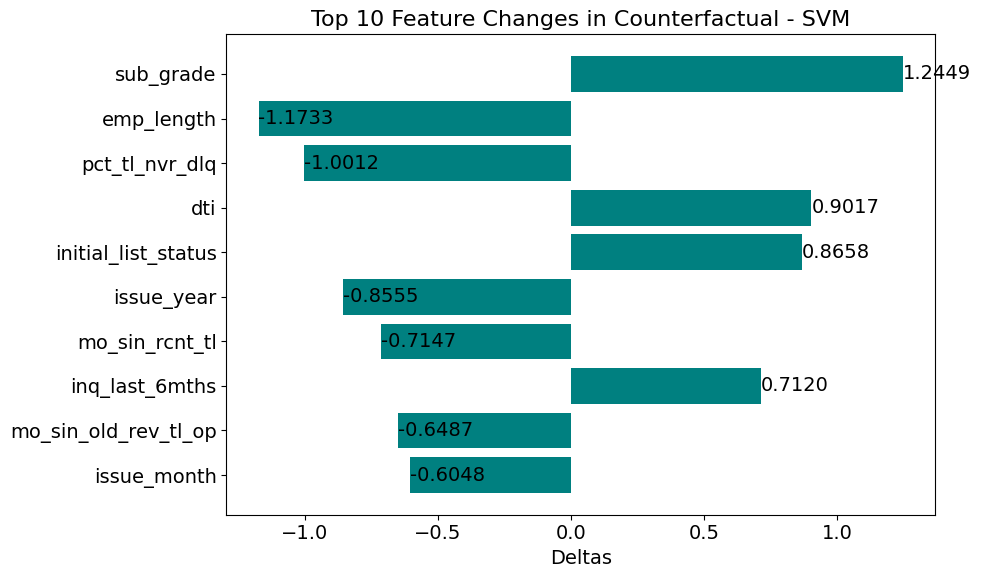

In [57]:
if counterfactuals.shape[0] == 0:
    print(f"Couldn't find any valid alternative instance for the instance with index {idx}")
else:
    # Plot horizontal bar chart
    plt.figure(figsize=(10,6))
    bars = plt.barh(df_top10["feature"], df_top10["delta"], color='teal')
    plt.xlabel("Deltas")
    plt.title("Top 10 Feature Changes in Counterfactual - SVM")
    
    # Add labels
    for bar, val in zip(bars, df_top10["delta"]):
        plt.text(bar.get_width() + 0.001 if val > 0 else bar.get_width() - 0.001, 
                 bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center')
    
    plt.gca().invert_yaxis()  # largest on top
    
    plt.savefig('intermediate_output/XAI top 10 features graphs/SVM_counterfactual_top10',dpi=300)
    plt.tight_layout()
    plt.show()

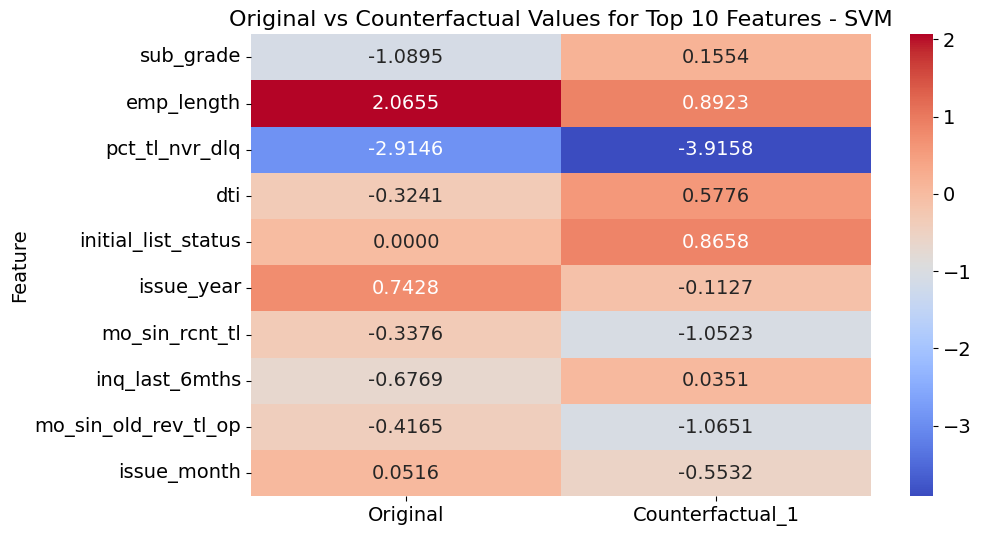

In [58]:
if counterfactuals.shape[0] == 0:
    print(f"Couldn't find any valid alternative instance for the instance with index {idx}")
else:
    # heatmap to see original vs counterfactual values
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df_top10[['feature','Original', 'Counterfactual_1']].set_index('feature'),
        annot=True,
        fmt=".4f",
        cmap='coolwarm',
        yticklabels=True
    )
    plt.title('Original vs Counterfactual Values for Top 10 Features - SVM')
    plt.ylabel('Feature')
    plt.show()